In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Correlation across all genes

In [2]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

abs_phenotypes = True

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_wgs.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1


In [3]:
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/annotation_files/genebass352genes_olink371genes_annotated_251205.parquet -o /home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet

# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/annotation_files/genebass352genes_olink371genes_annotated_251205_fillna.parquet -o /home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

Error: path "/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


In [4]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Choose Gene Body
        ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    # .with_columns(
    #     core_promoter = pl.col('dist_to_tss').abs() <= 50,
    #     encode_annotated = pl.col('not_in_encode') == False,
    #     encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
    #     encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    # )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        # set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

consequence_splice_acceptor_variant,five_prime_utr_variant_consequence_uaug_lost,consequence_synonymous_variant,consequence_frameshift_variant,ted_domain,encode_pls,esmscoremissense,gpn_score,pangolin_score,score_pai3d,mobi_curated_disorder_priority,encode_pels,abexp_abs_max,five_prime_utr_variant_consequence_ustop_lost,relative_cds_position,id,verphylop,region,consequence_stop_lost,encode_dels,absplice2_max,consequence_missense_variant,consequence_stop_gained,consequence_start_lost,mobi_lip_full,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_uaug_gained,low_complexity_domain,encode_tf,loftee_lc,am_pathogenicity,promoterai,delta_score,cadd_raw,loftee_hc,consequence_splice_donor_variant
i8,u8,i8,i8,bool,bool,f32,f32,f32,f32,bool,bool,f32,u8,f32,str,f32,str,i8,bool,f32,i8,i8,i8,bool,u8,u8,bool,bool,i8,f32,f32,f32,f32,i8,i8
0,0,0,0,false,false,0.0,-2.15,0.01,0.0,false,false,0.005917,0,0.0,"""chr2:26136528:A:G""",-0.458,"""ENSG00000084733""",0,true,0.000034,0,0,0,false,0,0,false,false,0,0.0,0.0,0.0,-0.065577,0,0
0,0,0,0,false,false,0.0,-0.93,0.0,0.0,false,false,0.019552,0,0.0,"""chr2:233771145:C:T""",-0.741,"""ENSG00000241119""",0,false,0.000033,0,0,0,false,0,0,false,false,0,0.0,0.0,0.0,0.065026,0,0
0,0,0,0,false,false,0.0,-1.51,0.0,0.0,false,false,0.006774,0,0.0,"""chr12:101117325:T:G""",0.064,"""ENSG00000151572""",0,false,0.0,0,0,0,false,0,0,false,false,0,0.0,0.0,0.0,0.675173,0,0
0,0,0,0,false,false,0.0,-1.7,0.0,0.0,false,false,0.006286,0,0.0,"""chr10:25235985:T:G""",0.474,"""ENSG00000151025""",0,false,0.000033,0,0,0,false,0,0,false,false,0,0.0,0.0,0.0,-0.324639,0,0
0,0,0,0,false,false,0.0,-1.84,0.0,0.0,false,false,0.006063,0,0.0,"""chr11:14154982:C:G""",0.295,"""ENSG00000262655""",0,false,0.000033,0,0,0,false,0,0,false,false,0,0.0,0.0,0.0,0.609409,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,0,0,false,false,0.0,0.0,0.0,0.0,false,false,0.006189,0,0.0,"""chr11:93791677:G:C""",0.355,"""ENSG00000042429""",0,false,0.000033,0,0,0,false,0,0,false,false,0,0.0,0.0,0.0,0.291896,0,0
0,0,0,0,false,false,0.0,-0.09,0.0,0.0,false,false,0.006286,0,0.0,"""chr7:90733917:A:C""",0.22,"""ENSG00000058091""",0,false,0.0,0,0,0,false,0,0,false,false,0,0.0,0.0,0.0,0.676461,0,0
0,0,0,0,false,false,0.0,-1.35,0.0,0.0,false,false,0.006189,0,0.0,"""chr18:754318:C:G""",-0.304,"""ENSG00000176105""",0,false,0.000033,0,0,0,false,0,0,false,false,0,0.0,0.0,0.0,-0.072338,0,0


In [5]:
selected_annos = anno_config_df.filter(
    (pl.col('category').is_in(['plof' ,'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'])) # CDS
    # pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
)['annotation'].to_list()

melted_anno = (
    anno
    
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    ).with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr2:26136528:A:G""","""ENSG00000084733""","""loftee_hc""",0.0
"""chr2:233771145:C:T""","""ENSG00000241119""","""loftee_hc""",0.0
"""chr12:101117325:T:G""","""ENSG00000151572""","""loftee_hc""",0.0
"""chr10:25235985:T:G""","""ENSG00000151025""","""loftee_hc""",0.0
"""chr11:14154982:C:G""","""ENSG00000262655""","""loftee_hc""",0.0
…,…,…,…
"""chr11:93791677:G:C""","""ENSG00000042429""","""abexp_abs_max""",0.006189
"""chr7:90733917:A:C""","""ENSG00000058091""","""abexp_abs_max""",0.006286
"""chr18:754318:C:G""","""ENSG00000176105""","""abexp_abs_max""",0.006189


In [6]:
# Subset Olink RVAT significant
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/proteomics_prs_am_loftee_mac20_burden_regression_results.parquet -o /home/dnanexus/data_dir/olink/proteomics_prs_am_loftee_mac20_burden_regression_results.parquet
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/proteomics_prs_loftee_mac20_burden_regression_results.parquet -o /home/dnanexus/data_dir/proteomics_prs_loftee_mac20_burden_regression_results.parquet

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/olink_all_mac20_lofteeHC_correlations.parquet -o /home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet

olink_whitelist = (
    pl.read_parquet('/home/dnanexus/data_dir/proteomics_prs_loftee_mac20_burden_regression_results.parquet')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir/proteomics_prs_loftee_mac20_burden_regres
sion_results.parquet" already exists but -f/--overwrite was not set
Error: path
"/home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet"
already exists but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000163606""","""ENSG00000163606_olink""",0.204082,0.204082,1.0
"""ENSG00000144857""","""ENSG00000144857_olink""",0.162616,0.162616,1.0
"""ENSG00000161270""","""ENSG00000161270_olink""",0.175562,0.175562,1.0
"""ENSG00000091129""","""ENSG00000091129_olink""",0.165924,0.165924,1.0
"""ENSG00000132437""","""ENSG00000132437_olink""",0.214824,0.214824,1.0
…,…,…,…,…
"""ENSG00000101160""","""ENSG00000101160_olink""",0.386419,0.386419,1.0
"""ENSG00000130528""","""ENSG00000130528_olink""",0.305544,0.305544,1.0
"""ENSG00000110448""","""ENSG00000110448_olink""",0.337765,0.337765,1.0


In [ ]:
# Read Olink phenotype data

# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/olink_cov_pcs_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/olink_cov_pcs_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet

# olink_appv = pl.scan_parquet("/home/dnanexus/olink_cov_pcs_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet.parquet")

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet

olink_appv = pl.scan_parquet("/home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet")

# Merge phenotype data and annotation data
final_lazy_plan = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .join(
        olink_whitelist.lazy(),
        on=["region", "phenotype"],
        how="semi"
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('phenotype')
    )
    .with_columns(
        pl.col(c)
        .rank("max")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None) # None maps to NaN for float columns
    )

    .filter(pl.col('annotation')!='loftee_hc')
    .select(['region', 'phenotype', 'annotation', 'n_variants', 'correlation'])

    .drop_nans().drop_nulls()

    .collect(engine='streaming')
)

# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    final_lazy_plan

    .join(
        anno_config_df,
        on='annotation'
    )
    .join(
        olink_whitelist,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

correlation_df

Error: path "/home/dnanexus/olink_cov_pcs_prs_rint_all_genes_EURunrelated_appv
_percentiles.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_ap
pv_percentiles.parquet" already exists but -f/--overwrite was not set


region,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,str,i8,f64,f64,f64,f64,f64
"""ENSG00000164303""","""ENSG00000164303_olink""","""esmscoremissense""",9072,-0.111036,"""missense""","""#feb72d""","""ESM1v""",-1,0.07785,0.07785,1.0,0.111036,1.426273
"""ENSG00000132002""","""ENSG00000132002_olink""","""absplice2_max""",2836,0.004708,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.212994,0.212994,1.0,0.004708,0.022102
"""ENSG00000116830""","""ENSG00000116830_olink""","""am_pathogenicity""",2833,0.05965,"""missense""","""#feb72d""","""AlphaMissense""",1,0.109063,0.109063,1.0,0.05965,0.546932
"""ENSG00000134365""","""ENSG00000134365_olink""","""abexp_abs_max""",2160,0.031982,"""regulatory_nondir""","""#80CBC4""","""AbExp abs max""",1,0.317493,0.317493,1.0,0.031982,0.100732
"""ENSG00000086102""","""ENSG00000086102_olink""","""am_pathogenicity""",5012,0.009909,"""missense""","""#feb72d""","""AlphaMissense""",1,0.11502,0.11502,1.0,0.009909,0.086148
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000163661""","""ENSG00000163661_olink""","""delta_score""",3078,0.031347,"""splicing""","""#28a745""","""SpliceAI""",1,0.275767,0.275767,1.0,0.031347,0.113674
"""ENSG00000116711""","""ENSG00000116711_olink""","""verphylop""",10716,0.009055,"""conservation""","""#942c80""","""Vertebrate PhyloP""",1,0.353331,0.353331,1.0,0.009055,0.025626
"""ENSG00000167851""","""ENSG00000167851_olink""","""gpn_score""",1201,-0.028185,"""conservation""","""#942c80""","""GPN-MSA""",-1,0.27326,0.27326,1.0,0.028185,0.103142


In [8]:
consistent_genes = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

filt_corr_df = correlation_df.join(consistent_genes, on=['region'], how='inner')
# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)  # Filter for groups with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df.sort('corr_beta', descending=True)

region,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,str,i8,f64,f64,f64,f64,f64
"""ENSG00000125458""","""ENSG00000125458_olink""","""esmscoremissense""",136,-0.600099,"""missense""","""#feb72d""","""ESM1v""",-1,0.145841,0.145841,1.0,0.600099,4.114754
"""ENSG00000125458""","""ENSG00000125458_olink""","""score_pai3d""",136,0.581215,"""missense""","""#feb72d""","""PrimateAI-3D""",1,0.145841,0.145841,1.0,0.581215,3.985271
"""ENSG00000125458""","""ENSG00000125458_olink""","""am_pathogenicity""",136,0.578359,"""missense""","""#feb72d""","""AlphaMissense""",1,0.145841,0.145841,1.0,0.578359,3.965687
"""ENSG00000125458""","""ENSG00000125458_olink""","""gpn_score""",136,-0.528275,"""conservation""","""#942c80""","""GPN-MSA""",-1,0.145841,0.145841,1.0,0.528275,3.622268
"""ENSG00000125458""","""ENSG00000125458_olink""","""cadd_raw""",136,0.508538,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.145841,0.145841,1.0,0.508538,3.486939
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000107821""","""ENSG00000107821_olink""","""cadd_raw""",371,0.222293,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,-0.080819,0.080819,-1.0,-0.222293,-2.750506
"""ENSG00000243509""","""ENSG00000243509_olink""","""score_pai3d""",2044,0.272839,"""missense""","""#feb72d""","""PrimateAI-3D""",1,-0.047987,0.047987,-1.0,-0.272839,-5.685661
"""ENSG00000107821""","""ENSG00000107821_olink""","""esmscoremissense""",371,-0.310655,"""missense""","""#feb72d""","""ESM1v""",-1,-0.080819,0.080819,-1.0,-0.310655,-3.843836


In [9]:
# Filter to only those with sign agreement
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 5
Inconsistent (region, phenotype) pairs: 0


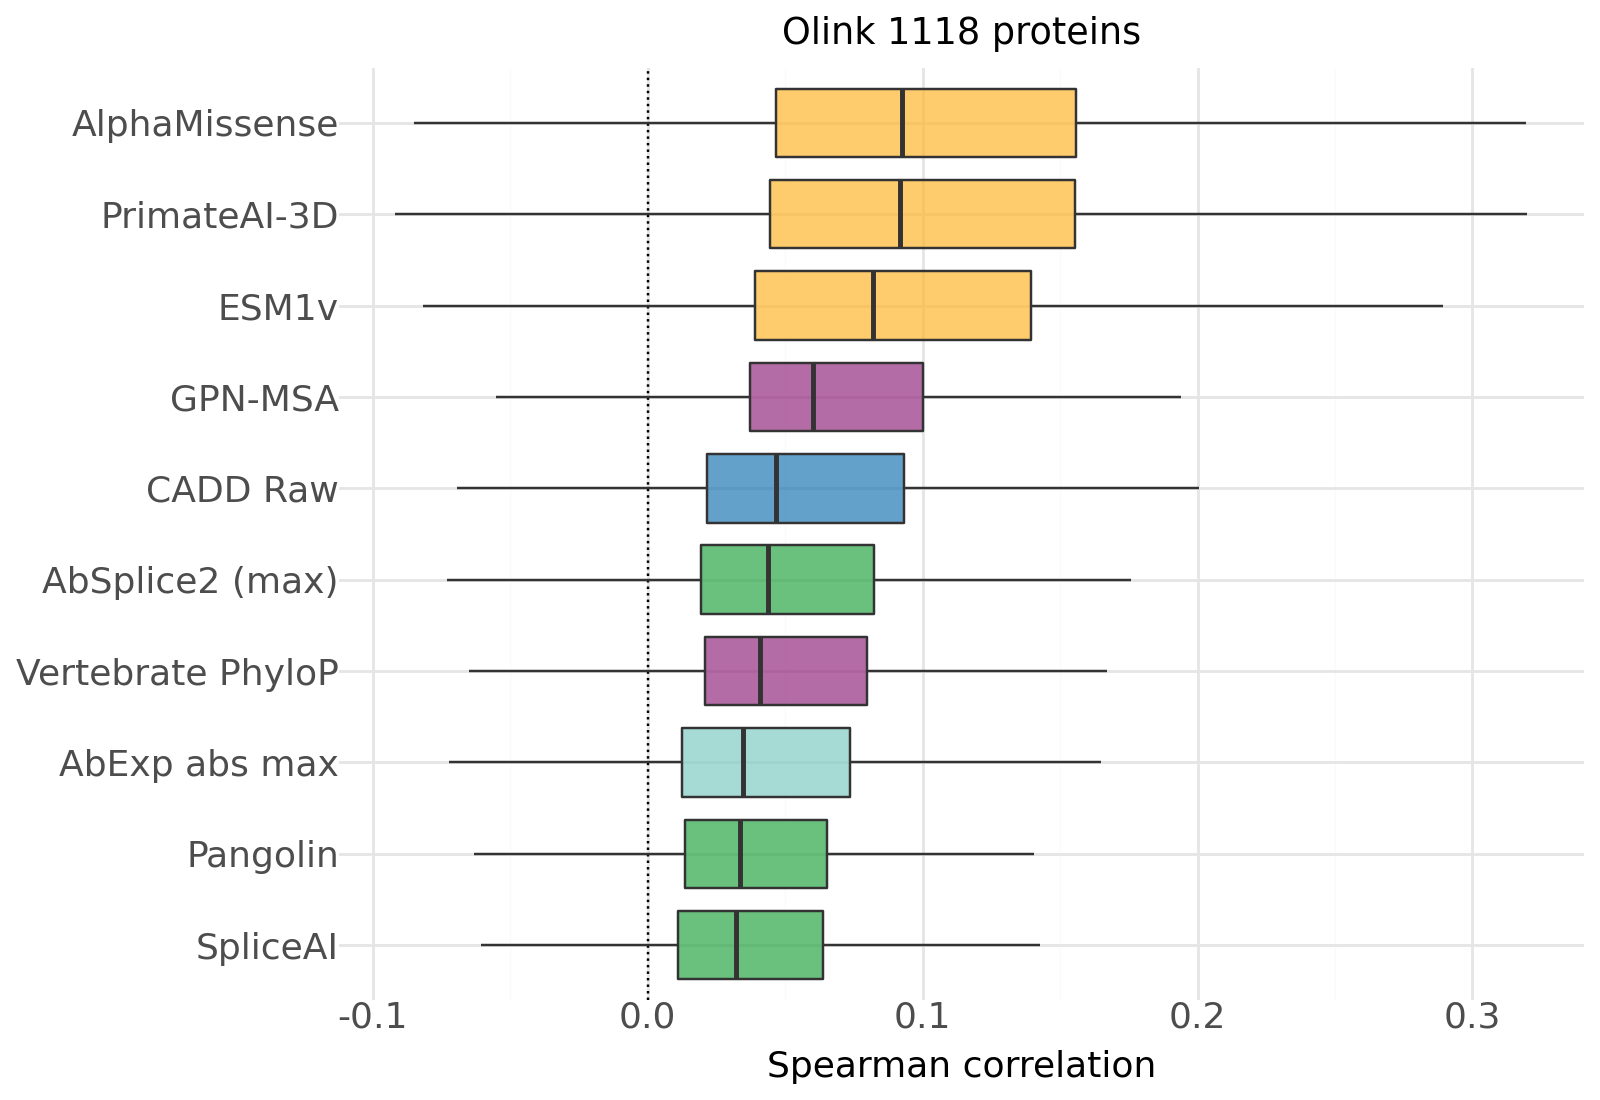

In [10]:
# Prepare for plotting
plotting_col = 'corr_beta'
# plotting_col = 'corr_beta_rescaled'

dashed_line_value = 1 if 'rescaled' in plotting_col else 0

med_df = filt_corr_df.drop_nans().group_by("annotation").agg(
    median_corr_beta = pl.col(plotting_col).median(),
)

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    # + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Olink {len(corr_pd['region'].unique())} proteins"
            # \nmissense variants"
            # \nGene body ±5kb"
            # \nTSS [{min_range}bp, {max_range}bp]"
            # \nsplice donor/acceptor variants"
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pd['annotation'].nunique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [11]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "corr_beta"])

    merged = df_a.join(df_b, on=["region"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_55119/863415217.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""am_pathogenicity""","""pangolin_score""",1064,35189.0,3.4444e-135
"""am_pathogenicity""","""delta_score""",1062,35713.0,3.1058e-134
"""abexp_abs_max""","""am_pathogenicity""",1086,40806.0,1.2952e-133
"""esmscoremissense""","""pangolin_score""",1093,46635.0,4.5773e-129
"""esmscoremissense""","""delta_score""",1091,48122.0,3.6321e-127
…,…,…,…,…
"""abexp_abs_max""","""delta_score""",1089,236955.0,8.4045e-9
"""cadd_raw""","""absplice2_max""",1093,249625.0,0.000002
"""pangolin_score""","""delta_score""",1091,256589.0,0.000074
